## 1. INTRODUCTION

### 1.1 Background

Airbnb is a digital platform that provides accommodation services with a wide range of property types, from private rooms to entire homes. In a major tourist destination such as Bangkok, the number of Airbnb listings has grown significantly, leading to increased competition among hosts.

Despite the large number of available listings, not all properties perform equally. Some listings receive frequent bookings and high engagement, while others remain underutilized despite being available throughout the year. This indicates a potential imbalance between **supply (availability)** and **demand (customer interest)** within the market.

Understanding this imbalance is crucial, as it can lead to inefficiencies where properties remain idle, reducing potential revenue for hosts and overall market performance.

In this analysis, demand is represented by the number of reviews, which serves as a proxy for customer bookings, as listings with more reviews generally indicate higher booking activity.

### 1.3 Business Context

This dataset provides valuable insights into Airbnb listing performance. By analyzing the relationship between supply (availability) and demand (reviews), it is possible to identify underperforming listings and develop strategies to improve occupancy and revenue.

### 1.4 Business Problem

Many Airbnb listings in Bangkok are not performing optimally, as they remain available for long periods without generating sufficient bookings, leading to missed revenue opportunities.

### 1.5 Problem Statement

There is a clear imbalance between supply and demand in the Airbnb market in Bangkok. A significant number of listings remain highly available throughout the year but receive low customer engagement, as indicated by a low number of reviews.

This suggests that many listings are underperforming and not effectively attracting customers despite being available.


To address this problem, a structured data analysis approach is conducted.

### 1.6 Objectives

This analysis aims to:

- Examine the relationship between supply (availability) and demand (reviews)
- Identify underperforming listings with high availability and low demand
- Analyze key factors influencing demand, including price, location, and room type
- Provide data-driven and actionable strategies to improve listing performance and market efficiency
  

#### 1.7 Analytical Question

- Does pricing significantly affect demand for Airbnb listings?
- How does listing quality influence customer engagement?
- Does visibility play a role in improving booking performance?
- Which strategy provides the highest impact in increasing demand?

## 2. DATA UNDERSTANDING

### 2.1 Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Airbnb Listings Bangkok.csv")

df.head()

,Unnamed: 0,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.75983,100.54134,Entire home/apt,1905,3,65,2020-01-06,0.50,2,353,0
1,1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.66818,100.61674,Private room,1316,1,0,NaN,NaN,2,358,0
2,2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.75232,100.62402,Private room,800,60,0,NaN,NaN,1,365,0
3,3,35780,Spacious one bedroom at The Kris Condo Bldg. 3,153730,Sirilak,Din Daeng,13.78823,100.57256,Private room,1286,7,2,2022-04-01,0.03,1,323,1
4,4,941865,Suite Room 3 at MetroPoint,610315,Kasem,Bang Kapi,13.76872,100.63338,Private room,1905,1,0,NaN,NaN,3,365,0


### 2.2 Dataset Overview

In [2]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15854 entries, 0 to 15853
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      15854 non-null  int64  
 1   id                              15854 non-null  int64  
 2   name                            15846 non-null  object 
 3   host_id                         15854 non-null  int64  
 4   host_name                       15853 non-null  object 
 5   neighbourhood                   15854 non-null  object 
 6   latitude                        15854 non-null  float64
 7   longitude                       15854 non-null  float64
 8   room_type                       15854 non-null  object 
 9   price                           15854 non-null  int64  
 10  minimum_nights                  15854 non-null  int64  
 11  number_of_reviews               15854 non-null  int64  
 12  last_review                     

The dataset contains **15,854 listings and 17 variables**, indicating a relatively large dataset suitable for comprehensive analysis.

The data consists of both numerical and categorical variables, including pricing, availability, location, and performance metrics, which provide a strong foundation for analyzing listing performance.

### 2.3 Data Dictionary

The dataset consists of mulitple variables that describe listing characteristics, host information, location, popularity, and availability.

- The **id** column represents a unique identifier assigned by Airbnb to each listing.It is used solely for identification and does not contribute to analytical insights.

- The **name** column contains the title of the listing provided by the host. It is descriptive and not used in quantitative analysis.

- The **host_id** contains the host's name and is not used in analysis due to its descriptive nature.

- The **neighbourhood** column represents the geographical area of the listing, derived through geocoding. Location is a critical factor influencing demand due to accessibility and attreactiveness.

- The **latitude** and **longitude** columns represent geographic coordinates based on the WGS84 system. These allow for spatial analysis, although this study focuses more on neighbourhood categories.

- The **room_type** column indicates the type of property offered, such as entire home, private room, shared room, or hotel room. This variable reflects market segmentation and customer preferences.

- The **price** column indicates the nightly rental price. It plays a significant role in customer decision-making and reflects the economic positioning of the listing.

- The **minimum_nights** column specifies the minimum number of nights required for booking, which may influence booking behavior.

- The **number_of_reviews** column specifies the minimum number of nights required for booking, which may influence booking behavior.

- The **last_review** column shows the date of the most recent review, but it is not central to this analysis.

- The **reviews_per_month** column indicates the average number of reviews per month, reflecting ongoing popularity.

- The **calculated_host_listings_count** column shows how many listings a host owns, helping distinguish berween individual and professional hosts.

- The **availability_365** column represents the number of days a listing is available in a year and is used as a procy for supply.

- The **number_of reviews_ltm** column shows the number of reviews in the las 12 months, reflecting recent performance.

### 2.4 Data Relevance

The selected variables play a key role in analyzing listing performance:

- number_of_reviews represents demand (customer interest)  
- availability_365 represents supply (listing availability)  
- price reflects market competitiveness  
- room_type and neighbourhood enable segmentation analysis  

These variables are essential for identifying underperforming listings and understanding the imbalance between supply and demand.

#### Key Analytival Assumption

In this study:
- **Demand** is represented by `number_of_reviews`
- **Supply** is represented by `availability_365`

This allows us to identify underperforming listings characterized by:

- **High availability + Low reviews**

### 2.5 Descriptive Statistics

#### 2.5.1 Summary Statistics

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,15854.0,7.926500e+03,4.576800e+03,0.00000,3.963250e+03,7.926500e+03,1.188975e+04,1.585300e+04
id,15854.0,1.579397e+17,2.946015e+17,27934.00000,2.104509e+07,3.503734e+07,5.256154e+07,7.908162e+17
host_id,15854.0,1.541058e+08,1.318726e+08,58920.00000,3.974431e+07,1.224556e+08,2.390547e+08,4.926659e+08
latitude,15854.0,1.374514e+01,4.303957e-02,13.52730,1.372009e+01,1.373849e+01,1.375950e+01,1.395354e+01
longitude,15854.0,1.005599e+02,5.091058e-02,100.32955,1.005297e+02,1.005614e+02,1.005851e+02,1.009234e+02
price,15854.0,3.217704e+03,2.497212e+04,0.00000,9.000000e+02,1.429000e+03,2.429000e+03,1.100000e+06
minimum_nights,15854.0,1.529236e+01,5.081502e+01,1.00000,1.000000e+00,1.000000e+00,7.000000e+00,1.125000e+03
number_of_reviews,15854.0,1.665416e+01,4.061333e+01,0.00000,0.000000e+00,2.000000e+00,1.300000e+01,1.224000e+03
reviews_per_month,10064.0,8.131449e-01,1.090196e+00,0.01000,1.200000e-01,4.350000e-01,1.060000e+00,1.913000e+01
calculated_host_listings_count,15854.0,1.388962e+01,3.026985e+01,1.00000,1.000000e+00,4.000000e+00,1.300000e+01,2.280000e+02


#### Interpretation
- The price distribution is right-skewed, indicating that most listings are concentrated in the lower price range, while a small number of listings are significantly more expensive.
- The number_of_reviews shows that many listings have very low engagement, suggesting that demand is not evenly distributed.
- The availability_365 variable has a wide range, indicating that some listings are frequently booked, while others remain available for most of the year.

### 2.6 Initial Insight

The analysis indicates that listing performance is uneven across the market.

A significant number of listings have high availability but low numbers of reviews, suggesting that they are not frequently booked despite being available.

**"This highlights a clear imbalance between supply and demand, where many listings remain underutilized."**

## 3. Data Cleaning

### 3.1 Missing Values 

In [4]:
df.isnull().sum().sort_values(ascending=False)

reviews_per_month                 5790
last_review                       5790
name                                 8
host_name                            1
Unnamed: 0                           0
neighbourhood                        0
latitude                             0
id                                   0
host_id                              0
room_type                            0
longitude                            0
minimum_nights                       0
price                                0
number_of_reviews                    0
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
dtype: int64

#### Findings

The results show that most variables do not contain missing values, except for a few columns:

- **reviews_per_month** => 5790 missing values
- **last_review** => 5790 missing values
- **name** => 8 missing values
- **host_name => 1 missing value

#### Interpertation:

The missing values in **reviews_per_month** and **last_review** are relatively high compared to other columns. However, this is expected because these fields depend on whether a listing has recived reviews.

- If a listing has no reviews, then:
  - `reviews_per_month` will be missing
  - `last_review` will also be missing

Therefore, these missing values do **not indicate data errors,** but rather eflect listings with **no customer engagement.**

The missing values in **name** and **host_name** are very small in number and are considered insignificant, meaning they will not affect the overall analysis.

This pattern indicates that missing values are not random, but systematically occur in listings with no customer activity.

#### Conclusion
Most of the dataset is complete, with missing values primarily occurring in review-related variables. These missing values are meaningful adn represent listings with no reviews, which aligns with the anlaysis objective of identifying low-demand listings.

### 3.2 Handling Missing Values
To handle missing values in the dataset, the following steps were performed:

In [5]:
df['reviews_per_month'].fillna(0, inplace=True)
df.drop(columns=['last_review'], inplace=True)

#### Handling Strategy & Justification
The missing values in **reviews_per_month** are replaced with **0**, as they indicate listings that have not received any reviews. Therefore, filling these values with 0 accurately reflects the absence of customer engagaement rather than treating them as missing or erroneous data.

The **last_review** column is removed from the dataset, as it is not directly relevant to the analysis of supply and demand. Additonally, this variable contains a large number of missing values and does not contribute significantly to identifying underperfoming listings.

For the **name** and **host_name** columns, the missing values are minimal and do not impact the overall analysis. Since these variables are not used in quantitative analysis, no further action is required.

#### Conclusion
The missing values in the dataset have been handled appropriately based on their context and relevance. Review-related missing values were interpreted as meaningful information, while non-essential variables were removed to simplify the dataset and improve analysis quality.

**This approach ensures that the dataset remains consistent while preserving meaningful information related to listing performance.**

### 3.3 Duplicate Data Handling
To identify duplicate records in the dataset, the following code was used: 

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop_duplicates(inplace=True)  # safe operation (no duplicates found)

#### Interpretaion & Justification

Duplicate data can introduce bias in the analysis, as the same listing may be counted multiple times, leading to inaccurate results.

In this dataset each row represents a unique Airbnb listing. Therefore, duplicate entries are not expected and are considered data inconsistencies.

After checking for duplicates, it was found that **no duplicate records exist in the dataset.**

#### Conclusion
Since no duplicate data is present, no removal is required. This confirms that the dataset maintains its integrity and each listing is uniquely represented.

### 3.4 Outlier Detection
To detect potential outliers in the price variable, a boxplot visualization is used:

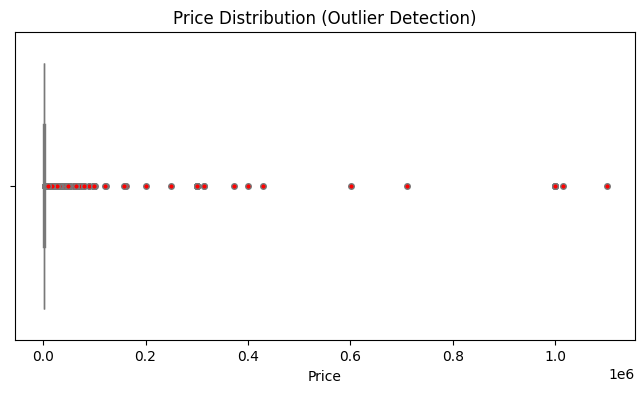

In [8]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['price'],
    color='lightblue',   # warna box
    flierprops=dict(marker='o', markerfacecolor='red', markersize=4)
)

plt.title("Price Distribution (Outlier Detection)")
plt.xlabel("Price")

plt.show()

#### Interpretation
The boxplot shows that the majority of price values are concentrated within a relatively low range, while several data poitns extend far beyond the upper quartile.  

These extreme value represent **high-price outliers**, which are significantly higher than the typical listing prices.

This pattern confirms that the price distribution is **right-skewed**, where a small number of listings have disproportionately high prices compared to the rest.

#### Insight
The presence of these high-value outliers suggests that while most listings are affordable, there is a small segment of **premium or luxury properties** in the market.

However, these extreme values can **distort statistical measures and visualizations**, making the overall distribution less representative of the majority of listings.

**This indicates that pricing in the market is highly uneven, with a few listings positioned far above the typical price range.**

#### 3.5 Handling Outliers
To reduce the impact of extreme values, a threshold is applied to filter out unsually high prices:

In [9]:
df = df[df['price'] < 1000]

#### Interpretation & Justification
The threshold of 1000 is selected based on the distribution of the data and the boxplot visualization. This threshold aligns with the upper range observed in the boxplot, where values above 1000 are clearly separated from the main distribution.

From the descriptiive statistics, most listings are priced within a significantly lower range, while values above 1000 are far beyond the upper quartile, indicating extreme outliers. The boxplot also shows that these values are clearly separataed from the main distribution.

**Key Justification:**
**Prices above 1000 are significantly higher than the majority of listings and can be considered extreme outliers.**

From a business perspective, such high prices are not representative of the typical Airbnb market and may correspond to luxury or exceptional properties.

#### Reasoning
This filtering is applied because:
- Extreme values can **distort statistical measures** such as the mean
- They can make visualizations

#### Conclusion
By removing prices above 1000, the dataset better reflects the main market segment, allowing for more accurate and meaningful analysis.

### 3.6 Validation

In [10]:
df.describe()
df.isnull().sum()

Unnamed: 0                        0
id                                0
name                              2
host_id                           0
host_name                         0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
dtype: int64

After data cleaning, the dataset shows no significant missing values and a more consistent distribution, indicating that the preprocessing steps were successfully applied.

**The data cleaning process improves data quality by reducing noise from missing values and extreme outliers, resulting in a dataset that better represents typical Airbnb listings.**

## 4. Exploratory Data Analysis (EDA)

### 4.1 Supply vs Demand 

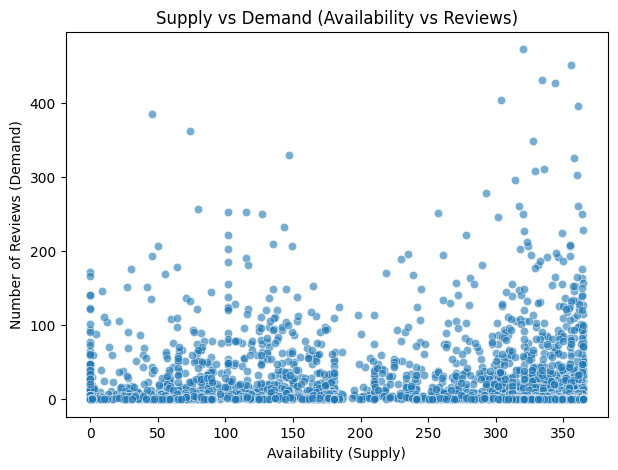

In [11]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='availability_365',
    y='number_of_reviews',
    data=df,
    alpha=0.6
)

plt.title("Supply vs Demand (Availability vs Reviews)")
plt.xlabel("Availability (Supply)")
plt.ylabel("Number of Reviews (Demand)")

plt.show()

#### Interpretation
Most listings **have low review counts,** indicating low demand. Listings with **high availability tend to have fewer reviews,** meaning they are often available but not frequently booked.

#### Insight
- **Many listings are underutilized, with high supply but low demand.**

This suggest a **supply-demand imbalance** in the market.
**This indicates that the issue lies in listing performance rather than availability.**

### 4.2 Price vs Demand

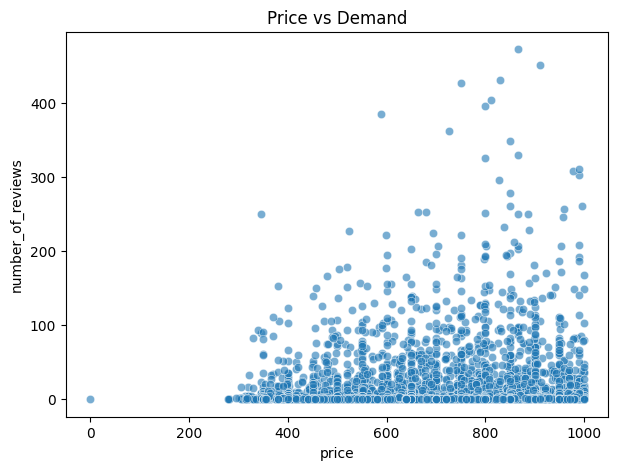

In [12]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='price',
    y='number_of_reviews',
    data=df,
    alpha=0.6
)

plt.title("Price vs Demand")
plt.show()

The scatter plot shows that listings across all price ranges can have both low and high numbers of reviews, indicating no clear linear relationship between price and demand.

The histogram reveals a right-skewed distribution, where most listings are concentrated in the lower to mid price range, while a smaller number of listings are priced significantly higher.

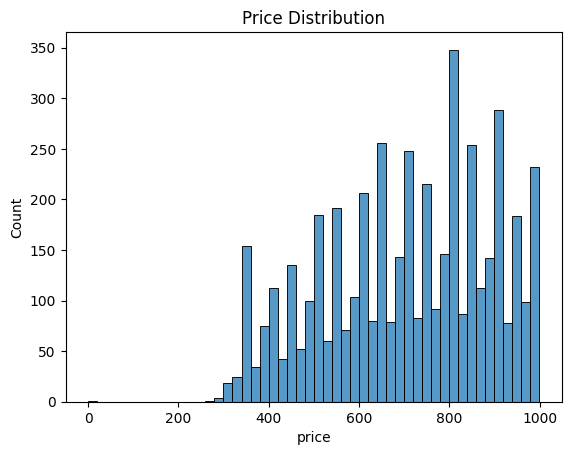

In [13]:
sns.histplot(df['price'], bins=50)
plt.title("Price Distribution")
plt.show()

The histogram shows that the price distribution is right-skewed, where most listings are concentrated in the lower to mid price range (approximately 400–900), while only a small number of listings are priced at the higher end.

This indicates that the majority of listings fall within a typical market price range, with fewer premium listings.

#### Insight

Price does not show a strong relationship with demand, as listings across different price ranges can have both low and high numbers of reviews.

This indicates that **higher prices do not necessarily lead to lower demand**, and **lower prices do not guarantee higher demand**.

Combined with the price distribution, this suggests that **pricing alone is not the primary driver of demand**. Instead, other factors such as listing quality, visibility, and customer perception may play a more significant role.

This pattern reinforces that the issue lies in listing performance rather than pricing strategy alone.

### 4.3 Room Type vs Demand

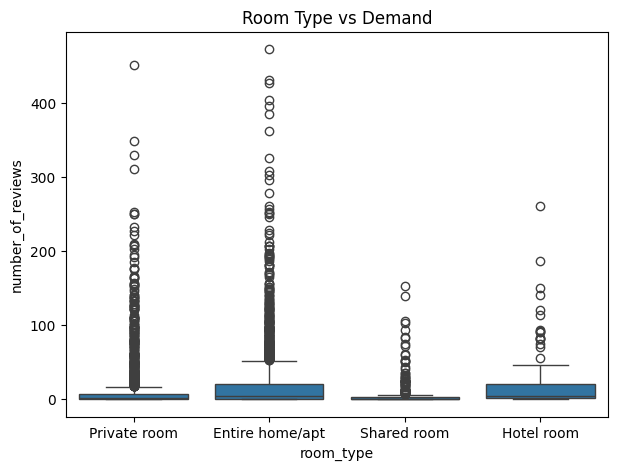

In [14]:
plt.figure(figsize=(7,5))

sns.boxplot(x='room_type', y='number_of_reviews', data=df)

plt.title("Room Type vs Demand")
plt.show()

#### Insight
**Demand varies across room types, with entire home/apt showing higher engagement compared to other types.**

Listings categorized as **entire home/apt** tend to have higher numbers of reviews, indicating stronger demand. In contrast, **shared rooms consistenly show the lowest demand,** while private rooms and hotel rooms fall in between.

This pattern reinforces that the issue lies in listing performance rather than supply shortage.

In [15]:
df[['price', 'availability_365', 'number_of_reviews']].describe()

,price,availability_365,number_of_reviews
count,4737.000000,4737.000000,4737.000000
mean,704.389065,246.884104,15.975934
std,184.128757,124.558948,38.494755
min,0.000000,0.000000,0.000000
25%,557.000000,146.000000,0.000000
50%,715.000000,307.000000,2.000000
75%,850.000000,362.000000,12.000000
max,999.000000,365.000000,472.000000


The descriptive statistics confirm that most listings have relatively low review counts and moderate availability, supporting the observation that demand is unevenly distributed.

### 4.4 Geographical Insight

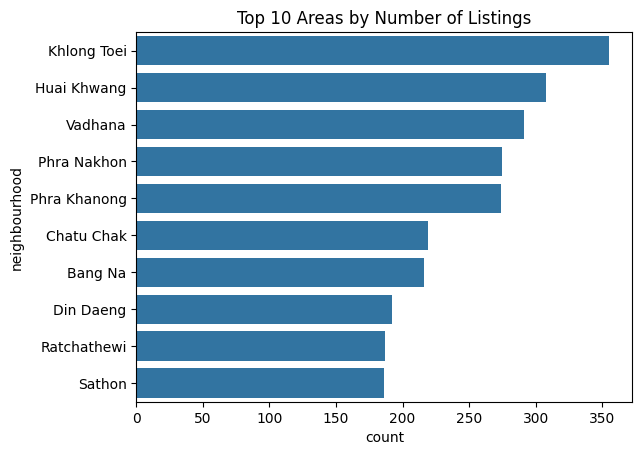

In [16]:
sns.countplot(
    y='neighbourhood', 
    data=df, 
    order=df['neighbourhood'].value_counts().index[:10]
)
plt.title("Top 10 Areas by Number of Listings")
plt.show()

Areas with a higher number of listings indicate higher competition among hosts, which may impact listing performance and visibility.

### 4.5 Correlation Analysis 

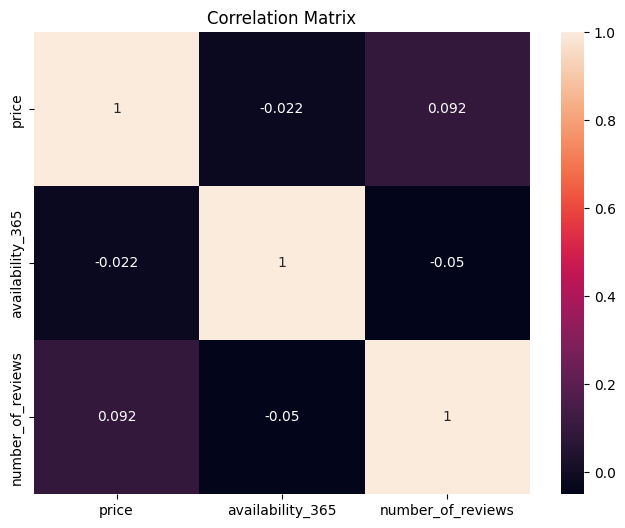

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['price','availability_365','number_of_reviews']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

#### Interpretation

The correlation matrix shows that there is no strong linear relationship between price, availability, and demand (number of reviews).

- The correlation between price and demand is very weak (0.092), indicating that price does not significantly influence the number of reviews.
- The correlation between availability and demand is slightly negative (-0.05), suggesting that listings with higher availability tend to have slightly lower demand, although the relationship is very weak.
- The correlation between price and availability is also negligible (-0.022), indicating no meaningful relationship between these variables.

#### Insight

**Demand is not strongly driven by a single variable such as price or availability, but is likely influenced by multiple factors acting together.**

This suggests that simply adjusting price or availability alone may not be sufficient to improve listing performance. Other factors such as listing quality, visibility, and customer perception likely play a more significant role in driving demand.

#### 4.6 Transition Segmentation

Based on the observed imbalance between supply and demand, and the lack of strong relationships between individual variables, a segmentation approach is needed to classify listings based on their performance.

## 5.Quadrant Analysis

### 5.1 Define Thresholds

In [18]:
## Pake Median biar ditengah nilainya
availability_median = df['availability_365'].median()
reviews_median = df['number_of_reviews'].median()

### 5.2 Create Segmentation

In [19]:
def segment(row):
    if row['availability_365'] >= availability_median and row['number_of_reviews'] < reviews_median:
        return 'Low Demand (Target)'
    elif row['availability_365'] < availability_median and row['number_of_reviews'] >= reviews_median:
        return 'High Demand'
    elif row['availability_365'] >= availability_median and row['number_of_reviews'] >= reviews_median:
        return 'Potential Growth'
    else:
        return 'Low Activity'

df['segment'] = df.apply(segment, axis=1)

### 5.3 Segment Distribution

In [20]:
df['segment'].value_counts(normalize=True) * 100

segment
High Demand            30.103441
Low Demand (Target)    26.261347
Potential Growth       23.918092
Low Activity           19.717121
Name: proportion, dtype: float64

A significant proportion of listings fall into the Low Demand segment, indicating that a large portion of the market is underutilized.

In [21]:
df[df['segment'] == 'Low Demand (Target)']['room_type'].value_counts()

room_type
Private room       690
Entire home/apt    367
Shared room        157
Hotel room          30
Name: count, dtype: int64

The Low Demand segment is dominated by certain room types, suggesting that property type may influence booking performance.

In [22]:
df.groupby('segment')['price'].mean()

segment
High Demand            729.870266
Low Activity           677.295503
Low Demand (Target)    681.983923
Potential Growth       719.253310
Name: price, dtype: float64

Average prices vary across segments, indicating that pricing strategy may contribute to differences in demand.

### 5.3 Visualisasi Quadrant

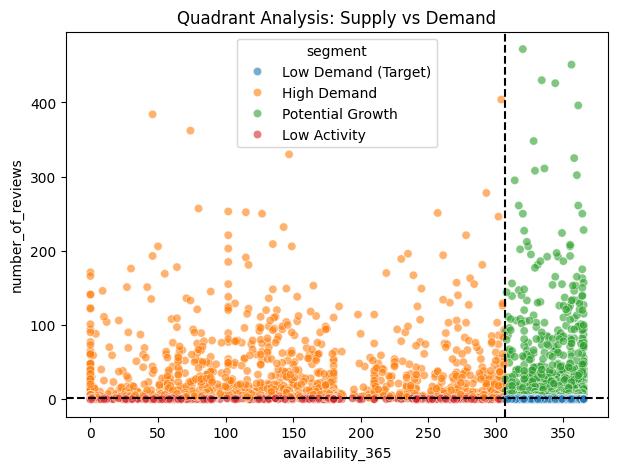

In [23]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='availability_365',
    y='number_of_reviews',
    hue='segment',
    data=df,
    alpha=0.6
)

plt.axvline(availability_median, linestyle='--', color='black')
plt.axhline(reviews_median, linestyle='--', color='black')

plt.title("Quadrant Analysis: Supply vs Demand")
plt.show()

#### Interpretation
The quadrant analysis segments listings based on supply (availability) and demand (number of reviews), revealing clear differences in listing performance.

Approximately 26% of listings fall into the **Low Demand** segment, making it one of the largest segments in the market.

This indicates that many listings are available but not frequently booked.

#### Key Insight

**The main issue in the market is not a lack of supply, but underperforming listings.**

## Business Insight

The dominance of listings in the Low Demand segment suggests that increasing supply alone will not improve market performance. Instead, the focus should be on improving the performance of existing listings.

#### Actionable Recommendations

**Primary Focus:**
- Prioritize listings in the Low Demand segment, as they represent the highest opportunity for improvement  

**Improvement Strategies:**
- Improve listing quality by enhancing photos, descriptions, and amenities  
- Optimize pricing strategies to align with market expectations  
- Increase visibility through promotions, instant booking, and better response rates  

This segmentation provides a clear and actionable framework for prioritizing business strategies and improving overall market efficiency.

## 6. Actionable Recommendations

Optimize pricing strategies for listings in the Low Demand segment  
- Improve listing quality (photos, descriptions, amenities)  
- Increase visibility through targeted promotions  
 
These strategies can help improve occupancy rates and overall market efficiency.

#### Simulation Assumptions

All simulations are based on reasonable assumptions derived from typical marketplace behavior, where improvements in pricing, listing quality, and visibility are expected to increase customer engagement at different magnitudes.

These simulations are used to estimate potential impact and do not represent exact causal relationships.

#### 6.1.1 Optimize Pricing Strategies
Adjust pricing for listings in the Low Deamnd segment by **reducing prices by approximately 10-20% below the segment average price.**

In [24]:
low_demand_avg = df[df['segment'] == 'Low Demand (Target)']['price'].mean()
low_demand_avg

np.float64(681.983922829582)

The average price for the Low Demand segment is approximately 682.

**Recommended price range:** 
- 10% reduction → ~614
- 20% reduction → ~546
  
Reducing prices to this range helps align listings with the main market segment, increasing their attractiveness to potential customers and improving booking probability.

Listings in the Low Demand segment should be priced between **546 – 614** to become more competitive and attract more bookings.

#### 6.1.2 Impact Simulation: Before vs After Pricing Adjustment
##### Concept
This simulation estimates the potential impact of price reduction on demand.

A moderate price reduction is assumed to increase demand due to improved competitiveness, particularly for price-sensitive customers.

We compare:
- Before: Original price and actual number of reviews
- After: Reduced price (10–20%) and estimated increase in reviews

#### Important Note

This simulation is based on assumptions and does not represent actual causal relationships. Further validation through real-world testing is required.

In [25]:
## Create Adjusted Price 
df['price_10pct'] = df['price'] * 0.9
df['price_20pct'] = df['price'] * 0.8

## Compare Price Distribution
df[['price', 'price_10pct', 'price_20pct']].describe()

,price,price_10pct,price_20pct
count,4737.000000,4737.000000,4737.000000
mean,704.389065,633.950158,563.511252
std,184.128757,165.715881,147.303005
min,0.000000,0.000000,0.000000
25%,557.000000,501.300000,445.600000
50%,715.000000,643.500000,572.000000
75%,850.000000,765.000000,680.000000
max,999.000000,899.100000,799.200000


In [26]:
## Simulate Demand Increase
df['reviews_10pct'] = df['number_of_reviews'] * 1.15 ## asumption 10 % price reduction → 15% increase in review 
df['reviews_20pct'] = df['number_of_reviews'] * 1.25 ## 20% price reduction → 25% increase in reviews

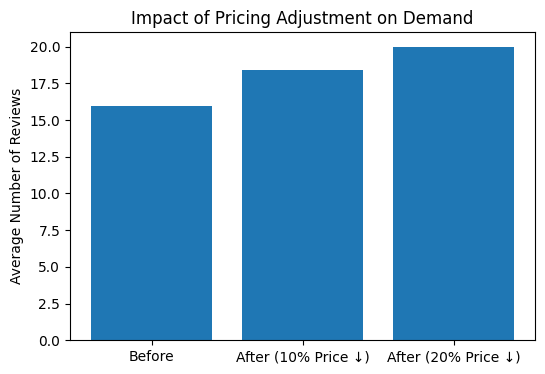

In [27]:
import matplotlib.pyplot as plt

# Calculate mean values
before = df['number_of_reviews'].mean()
after_10 = df['reviews_10pct'].mean()
after_20 = df['reviews_20pct'].mean()

# Data for plotting
labels = ['Before', 'After (10% Price ↓)', 'After (20% Price ↓)']
values = [before, after_10, after_20]

# Plot
plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("Impact of Pricing Adjustment on Demand")
plt.ylabel("Average Number of Reviews")

plt.show()

#### Interpretation

The chart shows that reducing prices by 10–20% is associated with an increase in estimated demand, as reflected by higher average reviews.

**This suggests that price adjustments can improve competitiveness, especially for underperforming listings in the Low Demand segment.**

#### 6.2.1 Improve Listing Quality

Listings in the Low Demand segment often suffer from low engagement due to limited attractiveness and incomplete information. Improving listing quality can significantly increase customer trust and conversion rates.

##### Recommended Actions
- Use at least 5–10 high-quality photos that clearly showcase the property, including key areas such as bedrooms, bathrooms, and common spaces
- Write clear and engaging descriptions (100–200 words) that highlight unique selling points such as location, amenities, and nearby attractions
- Provide complete and essential amenities, including WiFi, air conditioning, kitchen access, and parking if available

##### Target Outcome
Increase listing engagement from:
- < 5 reviews → > 10 reviews
Improve perceived listing quality to match higher-performing segments

#### 6.2.2 Impact Simulation: Listing Quality Improvement
##### Concept
This simulation estimates the potential impact of improving listing quality on demand.

Improving listing quality is assumed to have a stronger impact on demand, as it directly affects customer perception, trust, and booking decisions.

We compare:

- Before: Original number of reviews
- After: Increased reviews based on improved listing quality

#### Important Note

This simulation is based on assumptions and does not represent actual causal relationships. Further validation through real-world testing is required.

In [28]:
## Simulate Review Increase

df['reviews_30pct'] = df['number_of_reviews'] * 1.3 ## Assume 30% increase in reviews
df['reviews_50pct'] = df['number_of_reviews'] * 1.5 ## Assume 50% increase in reviews

In [29]:
## Calculate Average Impact
before = df['number_of_reviews'].mean()
after_30 = df['reviews_30pct'].mean()
after_50 = df['reviews_50pct'].mean()

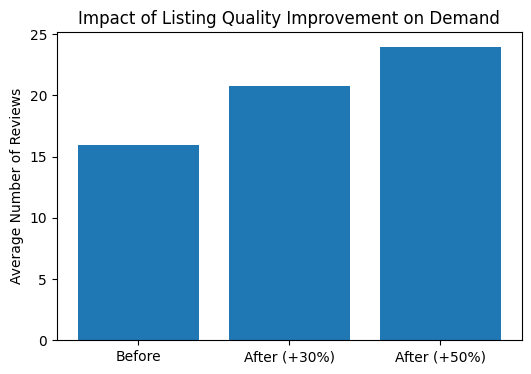

In [30]:
## Visualization (Before vs After)
labels = ['Before', 'After (+30%)', 'After (+50%)']
values = [before, after_30, after_50]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("Impact of Listing Quality Improvement on Demand")
plt.ylabel("Average Number of Reviews")

plt.show()

#### Interpretation 
The chart indicates that improving listing quality can lead to a noticeable increase in demand, as reflected by higher average review counts.

**Enhancing listing quality has strong potential to increase engagement and booking performance.**

#### Business Impact
- Higher booking conversion rates
- Increased customer trust
- Improved competitiveness of listings

#### Important Note

This simulation is based on assumptions and does not represent actual causal relationships. Further validation through real-world testing is required.

#### 6.3 Increase Visibility
Listings in the Low Demand segment may have low engagement not only due to pricing or quality, but also because they are less visible to potential customers. Increasing visibility can significantly improve exposure and booking opportunities.

##### Recommended Actions
- Apply promotional discounts (5–15%) to boost ranking and attract more clicks
- Enable instant booking to reduce friction and increase conversion
- Maintain a response rate above 90% to improve platform ranking
- Update listing activity regularly (calendar, pricing, availability) to stay relevant in search results

##### Target Outcome
Increase engagement from:

- 0–1 reviews/month → 2–4 reviews/month

Improve listing visibility and ranking within the platform

#### 6.3.2 Impact Simulation: Increasing Visibility
##### Concept

This simulation estimates the potential impact of increasing listing visibility on demand.

Increasing visibility is assumed to improve demand by exposing listings to more potential customers, thereby increasing the likelihood of bookings.

We compare:

- Before: Original number of reviews
- After: Increased reviews due to better visibility

#### Important Note

This simulation is based on assumptions and does not represent actual causal relationships. Further validation through real-world testing is required.

In [31]:
## Simulate Visibility Impact
df['reviews_visibility_20'] = df['number_of_reviews'] * 1.2 ## Increase from 20% 
df['reviews_visibility_35'] = df['number_of_reviews'] * 1.35 ## to 35% reviewsb

In [32]:
## Calculate Average
before = df['number_of_reviews'].mean()
after_20 = df['reviews_visibility_20'].mean()
after_35 = df['reviews_visibility_35'].mean()

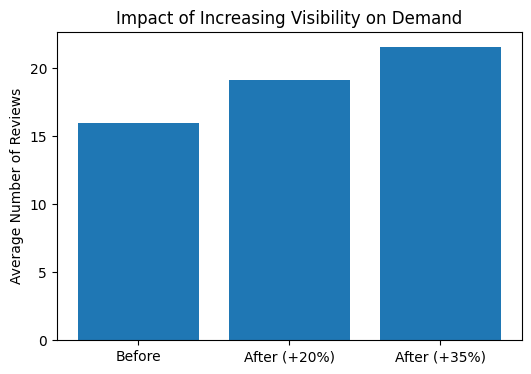

In [33]:
## Visualization
labels = ['Before', 'After (+20%)', 'After (+35%)']
values = [before, after_20, after_35]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("Impact of Increasing Visibility on Demand")
plt.ylabel("Average Number of Reviews")

plt.show()

#### Interpretation
The simulation suggests that increasing visibility can improve demand by exposing listings to more potential customers.

#### Key Insight
Higher visibility leads to more impressions and increases the likelihood of bookings.

#### Business Impact
- More listing exposure
- Increased booking opportunities
- Better utilization of available listings

#### Important Note

This simulation is based on assumptions and requires real-world validation.

#### 6.4 Combined Strategy Impact Analysis

To evaluate the effectiveness of different strategies, a combined analysis is conducted to compare the impact of pricing, listing quality, and visibility improvements on demand.

Instead of analyzing each strategy separately, this approach integrates all strategies into a single comparison to identify which strategy provides the highest potential impact.

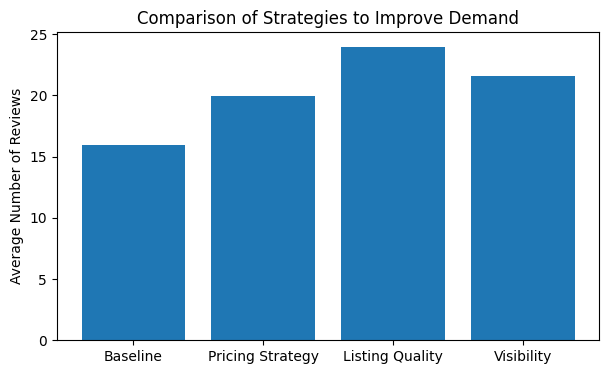

In [34]:
# Baseline (current demand)
baseline = df['number_of_reviews'].mean()

# Simulated impact of each strategy
pricing = (df['number_of_reviews'] * 1.25).mean()
quality = (df['number_of_reviews'] * 1.5).mean()
visibility = (df['number_of_reviews'] * 1.35).mean()

# Plot
labels = ['Baseline', 'Pricing Strategy', 'Listing Quality', 'Visibility']
values = [baseline, pricing, quality, visibility]

plt.figure(figsize=(7,4))
plt.bar(labels, values)

plt.title("Comparison of Strategies to Improve Demand")
plt.ylabel("Average Number of Reviews")

plt.show()

#### Interpretation

The chart shows a comparison of the estimated impact of different strategies on demand, measured by the average number of reviews.

All strategies demonstrate an improvement compared to the baseline. However, the increase varies across strategies, indicating that each approach contributes differently to enhancing listing performance.

#### Key Insight

**Improving listing quality delivers the highest impact on demand, making it the most effective primary strategy, followed by visibility and pricing adjustments.**

#### Business Recommendation
This prioritization ensures that resources are allocated efficiently to maximize impact on listing performance.

Based on the analysis, a prioritized strategy is recommended:

- Focus primarily on improving listing quality to maximize demand
- Enhance visibility as a secondary strategy to increase exposure
- Apply pricing adjustments as a supporting strategy to improve competitiveness

This approach ensures that resources are allocated to the most impactful areas.

This analysis highlights the importance of prioritizing high-impact strategies, enabling more effective decision-making to improve overall listing performance and market efficiency.

Overall, the analysis highlights that improving listing performance, not increasing supply, and the key to enhancing market efficiency and driving higher demand.

In [35]:
df.to_excel("clean_airbnb.xlsx", index=False)

,Unnamed: 0,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,...,number_of_reviews_ltm,segment,price_10pct,price_20pct,reviews_10pct,reviews_20pct,reviews_30pct,reviews_50pct,reviews_visibility_20,reviews_visibility_35
2,2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.75232,100.62402,Private room,800,...,0,Low Demand (Target),720.0,640.0,0.00,0.00,0.0,0.0,0.0,0.00
9,9,952677,Standard Room Decor do Hostel,5171292,Somsak,Khlong San,13.72040,100.50757,Private room,700,...,0,High Demand,630.0,560.0,4.60,5.00,5.2,6.0,4.8,5.40
13,13,59221,budget hotel bangkok near subway,284095,Mimi,Din Daeng,13.77941,100.57383,Entire home/apt,910,...,0,Potential Growth,819.0,728.0,3.45,3.75,3.9,4.5,3.6,4.05
31,31,1823321,กรองทองแมนชั่น (ลาดพร้าว 81),9545111,Penjit,Wang Thong Lang,13.78938,100.61340,Private room,600,...,0,Low Demand (Target),540.0,480.0,0.00,0.00,0.0,0.0,0.0,0.00
45,45,1016487,Private room in Bangkok,5594281,Yodying,Chatu Chak,13.82148,100.58326,Private room,350,...,0,Low Demand (Target),315.0,280.0,0.00,0.00,0.0,0.0,0.0,0.00


In [35]:
df['number_of_reviews'].mean()

np.float64(15.975934135528815)

In [36]:
df['reviews_10pct'].mean()

np.float64(18.372324255858135)

In [37]:
df['reviews_20pct'].mean()

np.float64(19.969917669411018)

In [38]:
df['reviews_30pct'].mean()

np.float64(20.76871437618746)

In [39]:
df['reviews_50pct'].mean()

np.float64(23.963901203293222)

In [40]:
df['reviews_visibility_20'].mean()

np.float64(19.17112096263458)

In [41]:
df['reviews_visibility_35'].mean()

np.float64(21.5675110829639)

In [44]:
data = {
    "Strategy": [
        "Baseline",
        "Pricing (10%)",
        "Quality (+30%)",
        "Visibility (+20%)"
    ],
    "Avg Reviews": [
        15.98,
        18.37,
        20.77,
        19.17
    ]
}

df_strategy = pd.DataFrame(data)

df_strategy

,Strategy,Avg Reviews
0,Baseline,15.98
1,Pricing (10%),18.37
2,Quality (+30%),20.77
3,Visibility (+20%),19.17


In [45]:
baseline = df_strategy.loc[0, "Avg Reviews"]

df_strategy["Improvement (%)"] = (
    (df_strategy["Avg Reviews"] - baseline) / baseline * 100
)

df_strategy

,Strategy,Avg Reviews,Improvement (%)
0,Baseline,15.98,0.000000
1,Pricing (10%),18.37,14.956195
2,Quality (+30%),20.77,29.974969
3,Visibility (+20%),19.17,19.962453


In [46]:
df_strategy.to_excel("strategy_impact.xlsx", index=False)